In [6]:
import pandas as pd

df1 = pd.read_csv("Healthcare Access and Quality Index.csv")
df2 = pd.read_csv("life-expectancy.csv")
df3 = pd.read_csv("annual-healthcare-expenditure-per-capita.csv")

print(df1.head())
print(df2.head())
print(df3.head())

print(df1.columns.tolist())
print(df2.columns.tolist())
print(df3.columns.tolist())

        Entity  Year  HAQ Index (IHME (2017))
0  Afghanistan  1990                     24.7
1  Afghanistan  1995                     24.5
2  Afghanistan  2000                     24.8
3  Afghanistan  2005                     27.1
4  Afghanistan  2010                     29.4
        Entity Code  Year  Life expectancy
0  Afghanistan  AFG  1950          28.1563
1  Afghanistan  AFG  1951          28.5836
2  Afghanistan  AFG  1952          29.0138
3  Afghanistan  AFG  1953          29.4521
4  Afghanistan  AFG  1954          29.6975
        Entity Code  Year  \
0  Afghanistan  AFG  2002   
1  Afghanistan  AFG  2003   
2  Afghanistan  AFG  2004   
3  Afghanistan  AFG  2005   
4  Afghanistan  AFG  2006   

   Current health expenditure per capita, PPP (current international $)  
0                                          85.857500                     
1                                          85.933020                     
2                                          93.935810                 

In [7]:
# Rename columns
df1 = df1.rename(columns={
    "Entity": "Country",
    "Year": "Year",
    "HAQ Index (IHME (2017))": "HAQ_Index"
})

df2 = df2.rename(columns={
    "Entity": "Country",
    "Year": "Year",
    "Life expectancy": "Life_Expectancy"
})

df3 = df3.rename(columns={
    "Entity": "Country",
    "Year": "Year",
    "Current health expenditure per capita, PPP (current international $)": "Health_Expenditure"
})

In [9]:
#Keep Only Needed Columns
df1 = df1[["Country", "Year", "HAQ_Index"]]
df2 = df2[["Country", "Year", "Life_Expectancy"]]
df3 = df3[["Country", "Year", "Health_Expenditure"]]

In [10]:
#Align Years
df1 = df1[(df1["Year"] >= 2002) & (df1["Year"] <= 2016)]
df2 = df2[(df2["Year"] >= 2002) & (df2["Year"] <= 2016)]
df3 = df3[(df3["Year"] >= 2002) & (df3["Year"] <= 2016)]

In [11]:
#Merge Datasets
df = df1.merge(df2, on=["Country", "Year"], how="inner")
df = df.merge(df3, on=["Country", "Year"], how="inner")

print(df.head())
print("Shape:", df.shape)

       Country  Year  HAQ_Index  Life_Expectancy  Health_Expenditure
0  Afghanistan  2005       27.1          58.2468          105.927704
1  Afghanistan  2010       29.4          60.7018          148.285740
2  Afghanistan  2015       32.5          62.2695          231.533660
3      Albania  2005       71.6          76.4266          328.991150
4      Albania  2010       75.3          78.4141          597.193240
Shape: (535, 5)


In [12]:
# Convert to numeric
df["HAQ_Index"] = pd.to_numeric(df["HAQ_Index"], errors="coerce")
df["Life_Expectancy"] = pd.to_numeric(df["Life_Expectancy"], errors="coerce")
df["Health_Expenditure"] = pd.to_numeric(df["Health_Expenditure"], errors="coerce")

# Drop missing values
df = df.dropna()

In [13]:
#create efficiency score
df["Efficiency_Score"] = df["HAQ_Index"] / df["Health_Expenditure"]

In [14]:
#saving cleaned Data set
df.to_csv("healthcare_final.csv", index=False)

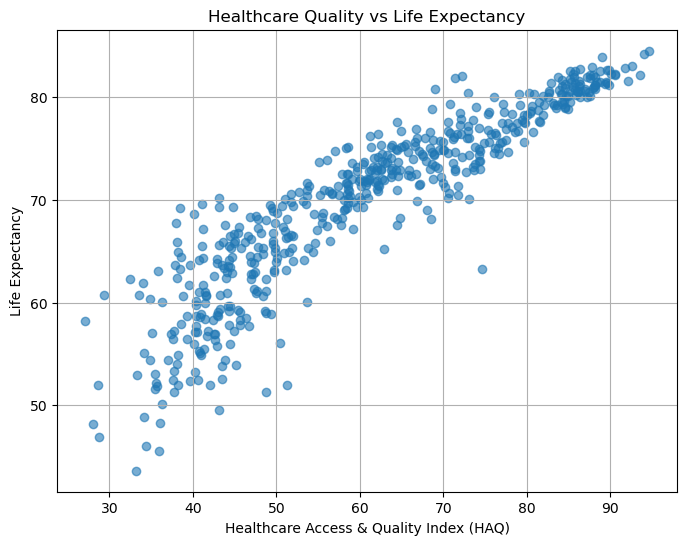

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["HAQ_Index"], df["Life_Expectancy"], alpha=0.6)

plt.xlabel("Healthcare Access & Quality Index (HAQ)")
plt.ylabel("Life Expectancy")
plt.title("Healthcare Quality vs Life Expectancy")

plt.grid(True)
plt.show()

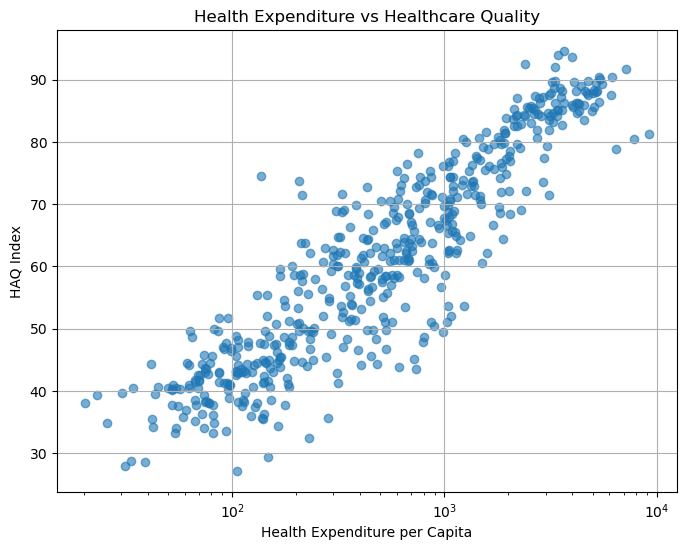

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(df["Health_Expenditure"], df["HAQ_Index"], alpha=0.6)

plt.xlabel("Health Expenditure per Capita")
plt.ylabel("HAQ Index")
plt.title("Health Expenditure vs Healthcare Quality")

plt.xscale("log")  # VERY IMPORTANT
plt.grid(True)
plt.show()

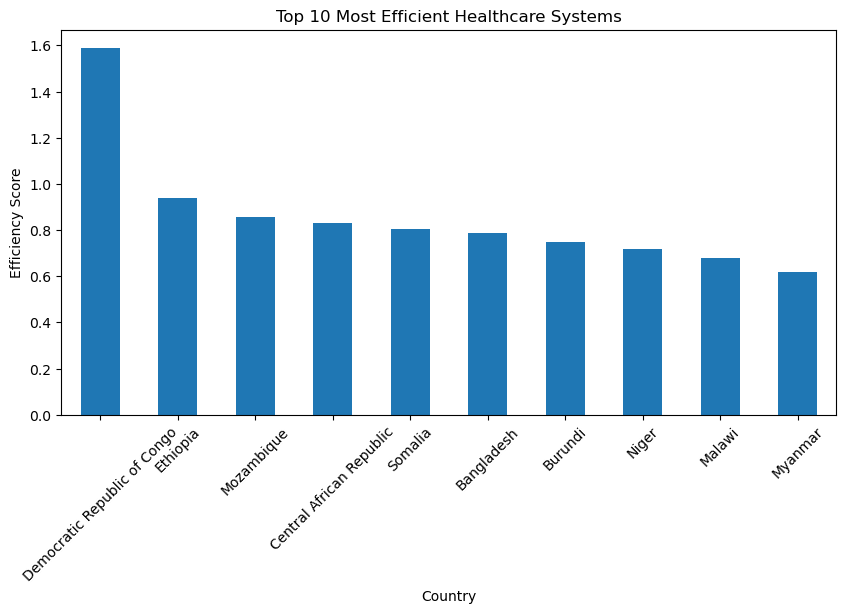

In [17]:
top_eff = df.groupby("Country")["Efficiency_Score"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_eff.plot(kind="bar")

plt.title("Top 10 Most Efficient Healthcare Systems")
plt.ylabel("Efficiency Score")
plt.xticks(rotation=45)
plt.show()

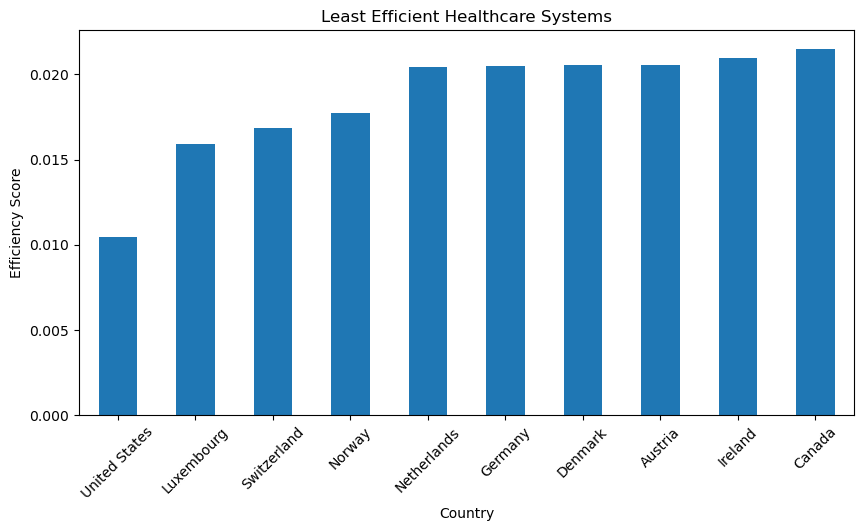

In [18]:
low_eff = df.groupby("Country")["Efficiency_Score"].mean().sort_values().head(10)

plt.figure(figsize=(10,5))
low_eff.plot(kind="bar")

plt.title("Least Efficient Healthcare Systems")
plt.ylabel("Efficiency Score")
plt.xticks(rotation=45)
plt.show()

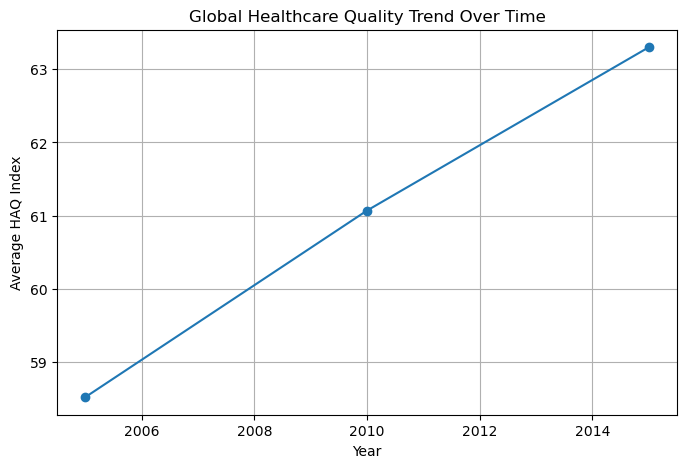

In [19]:
trend = df.groupby("Year")["HAQ_Index"].mean()

plt.figure(figsize=(8,5))
trend.plot(marker='o')

plt.title("Global Healthcare Quality Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average HAQ Index")
plt.grid()
plt.show()

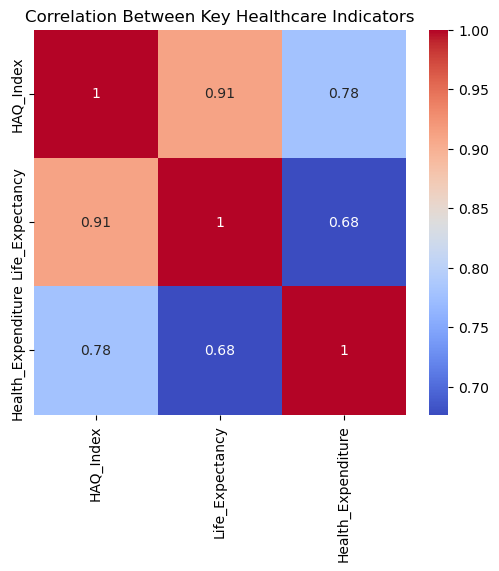

In [20]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df[["HAQ_Index","Life_Expectancy","Health_Expenditure"]].corr(), 
            annot=True, cmap="coolwarm")

plt.title("Correlation Between Key Healthcare Indicators")
plt.show()